#### Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

##### Load Dataset

In [3]:
df = pd.read_csv("Titanic-Dataset.csv")

##### Display First 5 Rows

In [8]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


##### Check Dataset Shape

In [9]:
df.shape

(891, 12)

#### Dataset Information

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


#### Check Data Types

In [12]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

#### Check Missing Values

In [13]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

#### Check Duplicate Records

In [16]:
df.duplicated().sum()

np.int64(0)

#### Descriptive Statistics

In [18]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


#### Check Value Range

In [19]:
df.describe(include="all")

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Braund, Mr. Owen Harris",male,NaN,NaN,NaN,347082,NaN,B96 B98,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


#### Data Quality Report (Before Cleaning)

In [20]:
report_before = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Data Type": df.dtypes
})

report_before

,Missing Values,Data Type
PassengerId,0,int64
Survived,0,int64
Pclass,0,int64
Name,0,object
Sex,0,object
Age,177,float64
SibSp,0,int64
Parch,0,int64
Ticket,0,object
Fare,0,float64


#### Observation
Checked dataset structure and data types.
Identified missing values and duplicate records.
Generated the initial data quality report before cleaning.

In [21]:
#### Handle Missing Values

In [22]:
# Fill Age with Median
df["Age"] = df["Age"].fillna(df["Age"].median())

# Fill Embarked with Mode
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Drop Cabin Column (Too Many Missing Values)
df = df.drop(columns=["Cabin"])

#### Missing Value Strategy
-- Age: Filled with the median because it is a numerical column.
-- Embarked: Filled with the mode because it is a categorical column.
-- Cabin: Dropped because most values are missing

In [24]:
## Remove Duplicate Records

In [25]:
duplicates = df.duplicated().sum()

df = df.drop_duplicates()

print("Duplicate Rows Removed:", duplicates)

Duplicate Rows Removed: 0


In [27]:
## Standardize Text Values

In [28]:
df["Sex"] = df["Sex"].str.strip().str.title()

df["Embarked"] = df["Embarked"].str.strip().str.upper()

In [29]:
## Correct Data Types

In [30]:
df["PassengerId"] = df["PassengerId"].astype(str)

In [31]:
## Check Updated Data Types

In [32]:
df.dtypes

PassengerId     object
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Embarked        object
dtype: object

In [33]:
## Check Missing Values After Cleaning

In [34]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

#### Observation
###### Missing values were handled successfully.
###### Duplicate rows were removed.
###### Text values were standardized.
###### Data types were corrected where required.

In [35]:
## Outlier Detection (IQR Method)

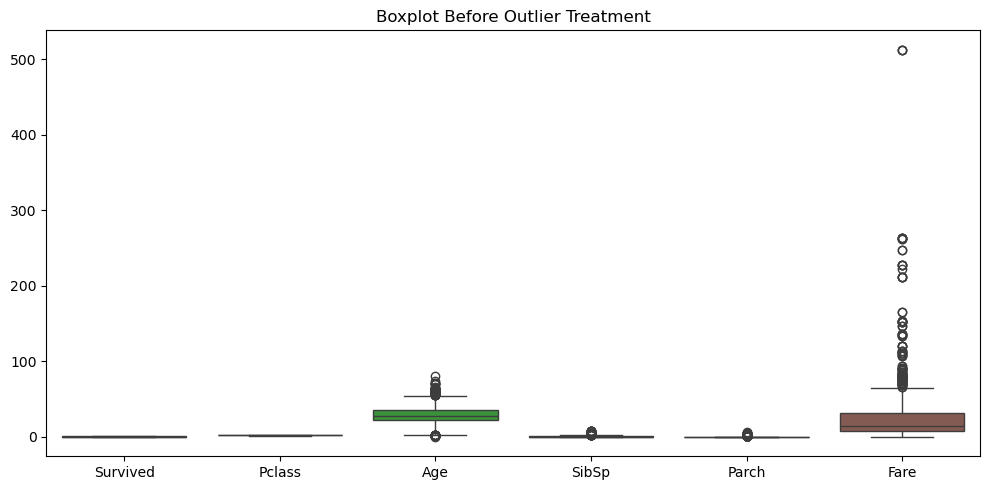

In [36]:
plt.figure(figsize=(10,5))

sns.boxplot(data=df.select_dtypes(include=np.number))

plt.title("Boxplot Before Outlier Treatment")

plt.tight_layout()
plt.savefig("outlier_boxplot_before.png", dpi=300, bbox_inches="tight")
plt.show()

In [37]:
## Remove Outliers

In [38]:
numeric_columns = ["Age", "Fare"]

for col in numeric_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower) & (df[col] <= upper)]

In [39]:
## Boxplot After Outlier Treatment

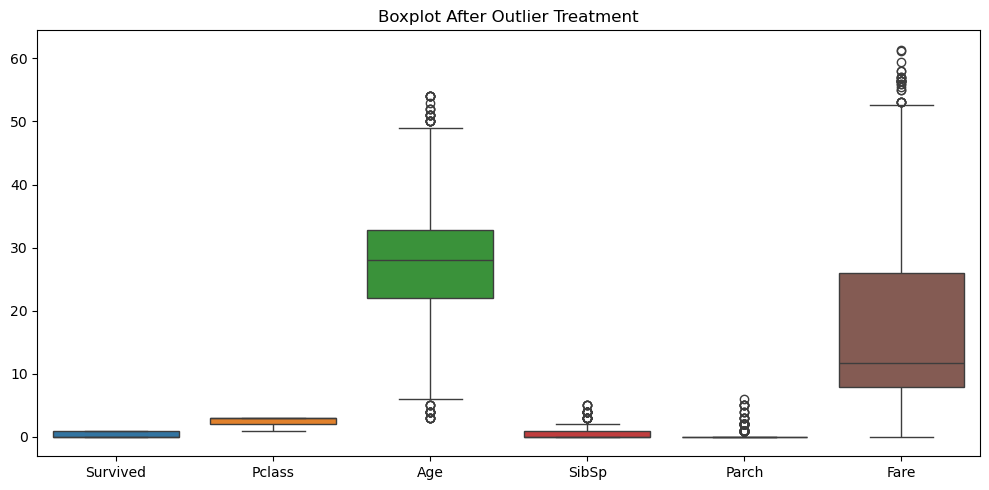

In [40]:
plt.figure(figsize=(10,5))

sns.boxplot(data=df.select_dtypes(include=np.number))

plt.title("Boxplot After Outlier Treatment")

plt.tight_layout()
plt.savefig("outlier_boxplot_after.png", dpi=300, bbox_inches="tight")
plt.show()

In [41]:
## Data Quality Report (After Cleaning)

In [42]:
report_after = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Data Type": df.dtypes
})

report_after

,Missing Values,Data Type
PassengerId,0,object
Survived,0,int64
Pclass,0,int64
Name,0,object
Sex,0,object
Age,0,float64
SibSp,0,int64
Parch,0,int64
Ticket,0,object
Fare,0,float64


In [43]:
## Before vs After Summary

In [44]:
summary = pd.DataFrame({
    "Metric": [
        "Rows",
        "Columns",
        "Missing Values",
        "Duplicate Rows"
    ],
    "Before Cleaning": [
        report_before.shape[0],
        df.shape[1] + 1,
        report_before["Missing Values"].sum(),
        duplicates
    ],
    "After Cleaning": [
        df.shape[0],
        df.shape[1],
        report_after["Missing Values"].sum(),
        df.duplicated().sum()
    ]
})

summary

,Metric,Before Cleaning,After Cleaning
0,Rows,12,718
1,Columns,12,11
2,Missing Values,866,0
3,Duplicate Rows,0,0


In [45]:
## Save Cleaned Dataset

In [46]:
df.to_csv("Cleaned_Titanic_Dataset.csv", index=False)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


## Conclusion
###### Missing values were handled using appropriate techniques.
###### Duplicate records were removed.
###### Text values and data types were standardized.
###### Outliers were identified using the IQR method and removed.
###### The cleaned dataset was saved as a new CSV file and is ready for analysis.